In [ ]:
! pip install pandas numpy matplotlib seaborn scikit-learn

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/content/adult.csv")

In [ ]:
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [ ]:
df.describe()

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


# Missing values

In [ ]:
print(df.isnull().sum())

age               0
workclass         0
fnlwgt            0
education         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
native.country    0
income            0
dtype: int64


# Gender Distribution

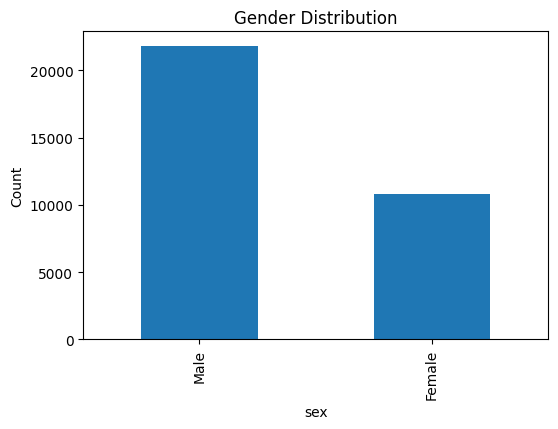

In [ ]:
gender = df["sex"].value_counts()

plt.figure(figsize=(6,4))
gender.plot(kind="bar")
plt.title("Gender Distribution")
plt.ylabel("Count")
plt.savefig("gender_distribution.png")
plt.show()

# Race Distribution

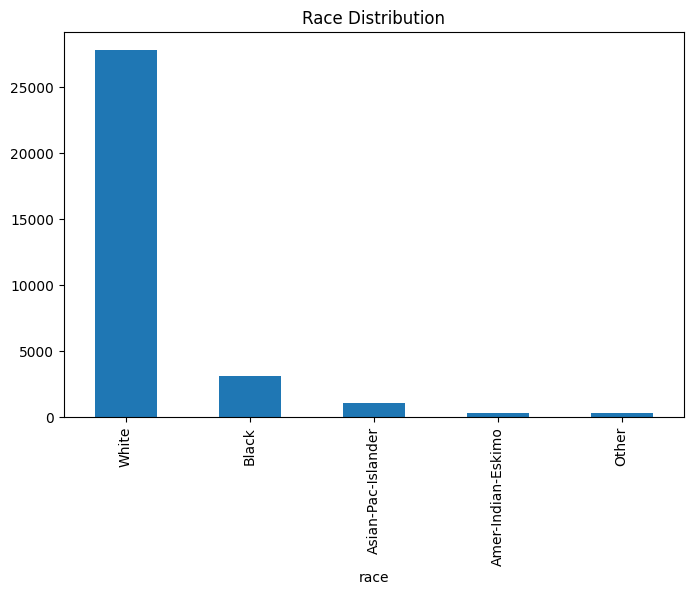

In [ ]:
race = df["race"].value_counts()

plt.figure(figsize=(8,5))
race.plot(kind="bar")
plt.title("Race Distribution")
plt.savefig("race_distribution.png")
plt.show()

# Income by Gender

income  <=50K  >50K
sex                
Female   9592  1179
Male    15128  6662


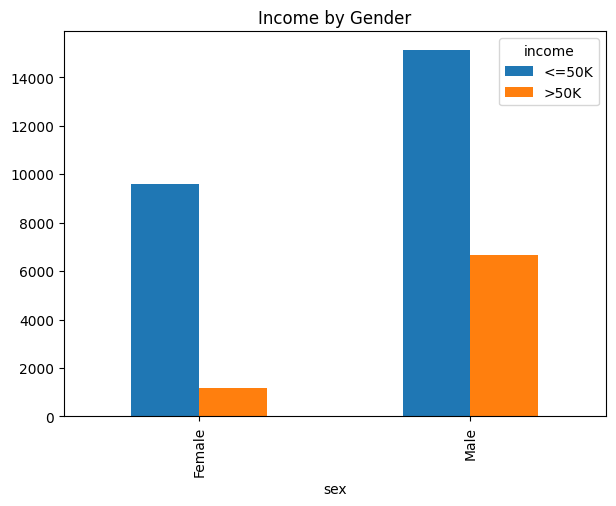

In [ ]:
income_gender = pd.crosstab(df["sex"], df["income"])

print(income_gender)

income_gender.plot(kind="bar", figsize=(7,5))
plt.title("Income by Gender")
plt.savefig("income_gender.png")
plt.show()

# Income by Race

income              <=50K  >50K
race                           
Amer-Indian-Eskimo    275    36
Asian-Pac-Islander    763   276
Black                2737   387
Other                 246    25
White               20699  7117


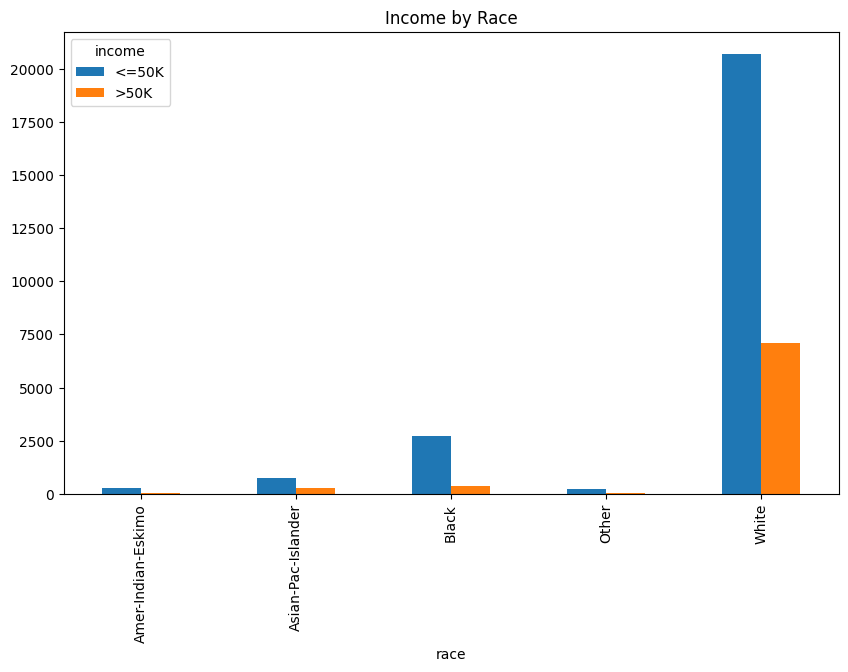

In [ ]:
income_race = pd.crosstab(df["race"], df["income"])

print(income_race)

income_race.plot(kind="bar", figsize=(10,6))
plt.title("Income by Race")
plt.savefig("income_race.png")
plt.show()

# Age Distribution

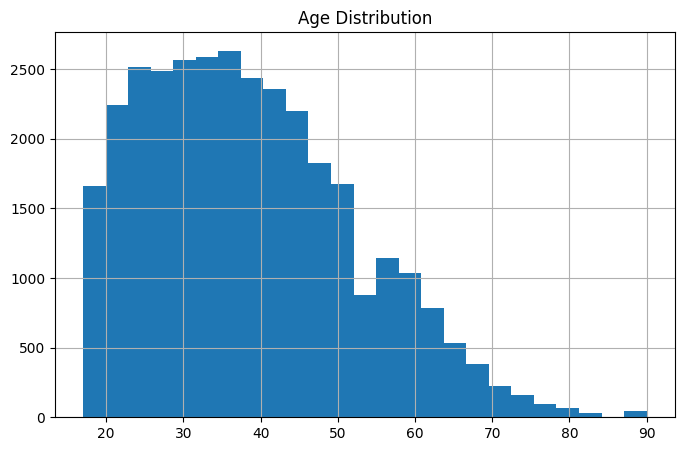

In [ ]:
plt.figure(figsize=(8,5))
df["age"].hist(bins=25)
plt.title("Age Distribution")
plt.savefig("age_distribution.png")
plt.show()

# Education Distribution

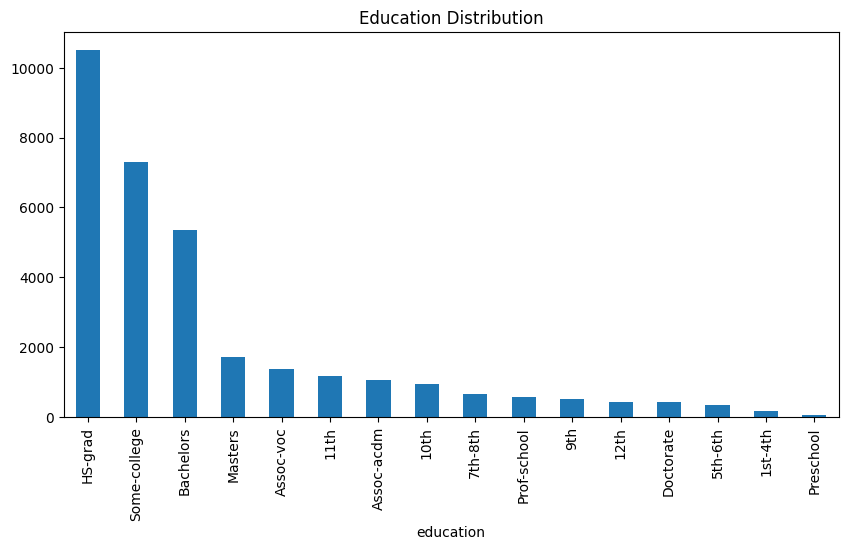

In [ ]:
edu = df["education"].value_counts()

plt.figure(figsize=(10,5))
edu.plot(kind="bar")
plt.title("Education Distribution")
plt.savefig("education_distribution.png")
plt.show()

# Percentage Above 50K

In [ ]:
print(df["income"].value_counts(normalize=True)*100)

income
<=50K    75.919044
>50K     24.080956
Name: proportion, dtype: float64


# Female vs Male >50K

In [ ]:
income_percent = pd.crosstab(df["sex"], df["income"], normalize="index")*100

income_percent

income,<=50K,>50K
sex,,
Female,89.053941,10.946059
Male,69.426342,30.573658


# Race Percentages

In [ ]:
race_percent = df["race"].value_counts(normalize=True)*100

race_percent

,proportion
race,
White,85.427352
Black,9.594300
Asian-Pac-Islander,3.190934
Amer-Indian-Eskimo,0.955130
Other,0.832284


# Correlation

In [ ]:
numeric = df.select_dtypes(include="number")

numeric.corr()

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
age,1.000000,-0.076646,0.036527,0.077674,0.057775,0.068756
fnlwgt,-0.076646,1.000000,-0.043195,0.000432,-0.010252,-0.018768
education.num,0.036527,-0.043195,1.000000,0.122630,0.079923,0.148123
capital.gain,0.077674,0.000432,0.122630,1.000000,-0.031615,0.078409
capital.loss,0.057775,-0.010252,0.079923,-0.031615,1.000000,0.054256
hours.per.week,0.068756,-0.018768,0.148123,0.078409,0.054256,1.000000
